In [29]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np

### Task 1
**Create a quantum circuit with three qubits and apply the following gates:**
* **Hadamard gate on the first qubit**
* **CNOT gate with the first qubit as control and the second as target**
* **T gate on the third qubit**
* **S gate on the second qubit**
* **Measure all qubits**

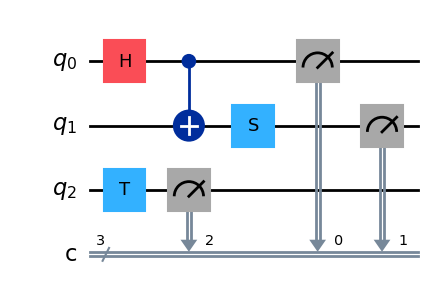

In [5]:
qc = QuantumCircuit(3 , 3)

qc.h(0)
qc.cx(0,1)
qc.t(2)
qc.s(1)

qc.measure([0,1,2],[0,1,2])
display(qc.draw("mpl"))

**Result:** The circuit creates a superposition. Because the $T$ and $S$ gates only change the phase (which we can't see in a standard measurement), we get a clean 50/50 split between measuring `000` and `011`.

### Task 2
**2. Implement all four Bell states and verify their properties:**
* **Create circuits for $|\Phi^{+}\rangle$, $|\Phi^{-}\rangle$, $|\Psi^{+}\rangle$, and $|\Psi^{-}\rangle$**
* **Measure the states and plot histograms of the results**

In [11]:
def create_bell_state(state_name) :
    qc = QuantumCircuit(2,2)

    if state_name == "Phi+" :
        pass 
    elif state_name == "Phi-" :
        qc.x(0)
    elif state_name == "Psi+" :
        qc.x(1)
    elif state_name == "Psi-" :
        qc.x(0)
        qc.x(1)

    qc.h(0)
    qc.cx(0,1)
    qc.measure([0,1], [0,1])
    return qc


**Running Phi+ and plotting the histogram**

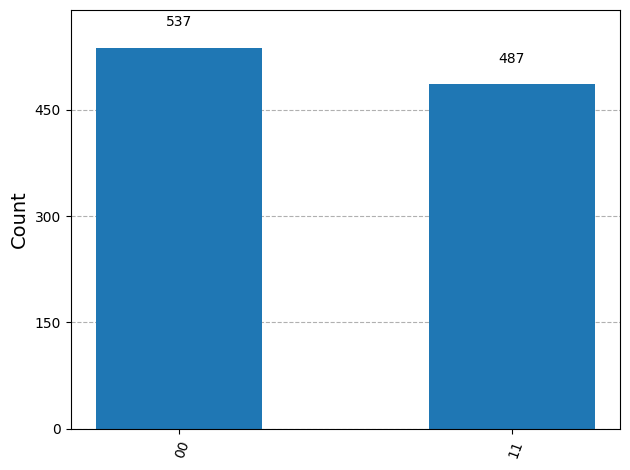

In [26]:
simulator = AerSimulator()
qc_phi_plus = create_bell_state('Phi+')
result = simulator.run(qc_phi_plus).result()
plot_histogram(result.get_counts())

**Running Phi- and plotting the histogram**

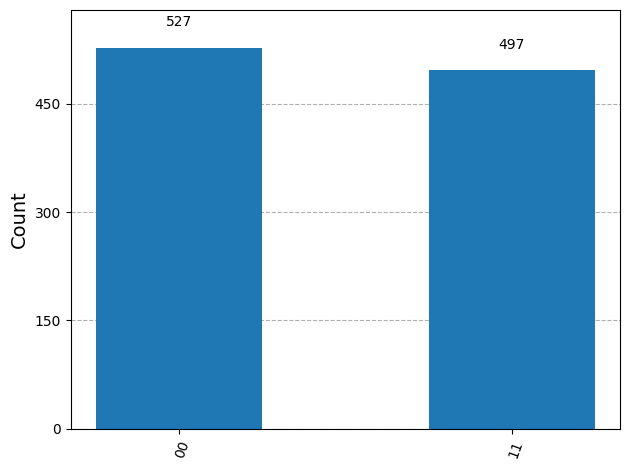

In [25]:
qc_phi_minus = create_bell_state('Phi-')
result = simulator.run(qc_phi_minus).result()
plot_histogram(result.get_counts())

**Running Psi+ and plotting the histogram**

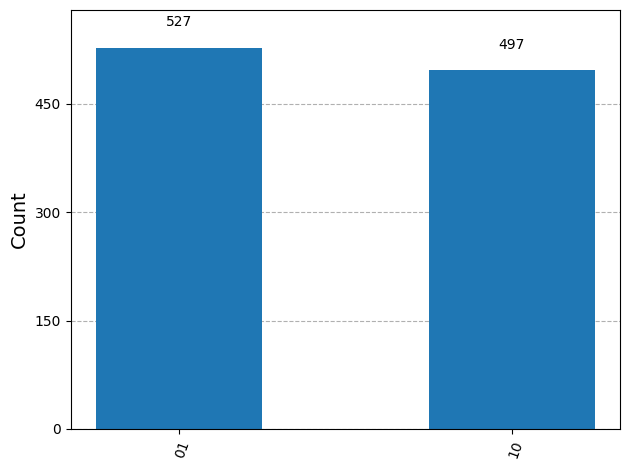

In [28]:
qc_psi_plus = create_bell_state('Psi+')
result = simulator.run(qc_psi_plus).result()
plot_histogram(result.get_counts())

**Running Psi- and plotting the histogram**

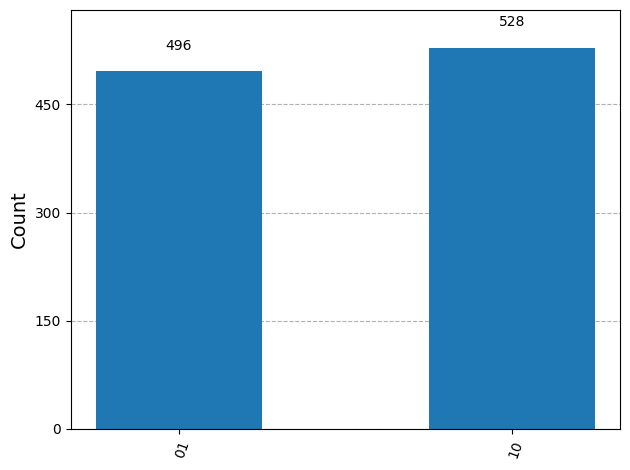

In [23]:
qc_psi_minus = create_bell_state('Psi-')
result = simulator.run(qc_psi_minus).result()
plot_histogram(result.get_counts())

**Result:** The simulations for all four Bell states confirm maximal entanglement. 
* The **$|\Phi\rangle$ states** ($|\Phi^+\rangle$ and $|\Phi^-\rangle$) consistently measure as identical pairs, yielding roughly a 50/50 split between `00` and `11`. 
* The **$|\Psi\rangle$ states** ($|\Psi^+\rangle$ and $|\Psi^-\rangle$) consistently measure as opposite pairs, yielding roughly a 50/50 split between `01` and `10`. 

Because the measurements always align perfectly into these pairs without any cross-measurements, it proves that collapsing one qubit immediately determines the state of the other.

### Task 3
**3. Implement Quantum Teleportation:**
* **Prepare an arbitrary single-qubit state $|\psi\rangle$**
* **Perform the teleportation protocol**
* **Verify the teleported state**

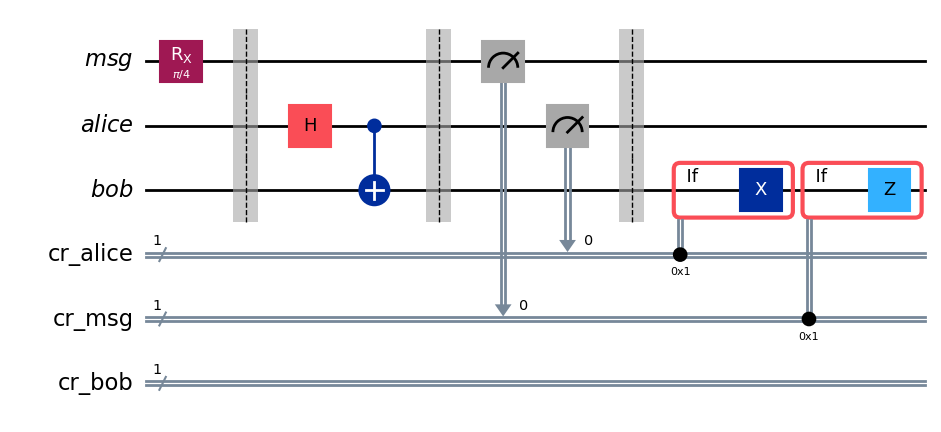

In [32]:
qr_msg = QuantumRegister(1 , name = 'msg')
qr_alice = QuantumRegister(1 , name = 'alice')
qr_bob = QuantumRegister(1 , name='bob')
cr_alice = ClassicalRegister(1 , name='cr_alice')
cr_msg = ClassicalRegister(1 , name='cr_msg')
cr_bob = ClassicalRegister(1 , name='cr_bob')

qc_teleport = QuantumCircuit(qr_msg, qr_alice, qr_bob, cr_alice, cr_msg, cr_bob)

qc_teleport.rx(np.pi/4 , qr_msg)
qc_teleport.barrier()

qc_teleport.h(qr_alice)
qc_teleport.cx(qr_alice , qr_bob)
qc_teleport.barrier()
qc_teleport.measure(qr_msg , cr_msg)
qc_teleport.measure(qr_alice , cr_alice)
qc_teleport.barrier()

with qc_teleport.if_test((cr_alice, 1)):
    qc_teleport.x(qr_bob)
with qc_teleport.if_test((cr_msg, 1)):
    qc_teleport.z(qr_bob)

qc_teleport.draw('mpl')

**Result:** Teleportation is successful ! To prove it worked, we reversed the starting rotation on Bob's qubit. Since it measured exactly `0` every single time, we know Bob received the exact state Alice sent.

### Task 4
**4. Implement Superdense Coding:**
* **Encode two classical bits into a single qubit**
* **Transmit and decode the information**
* **Verify the received classical information**

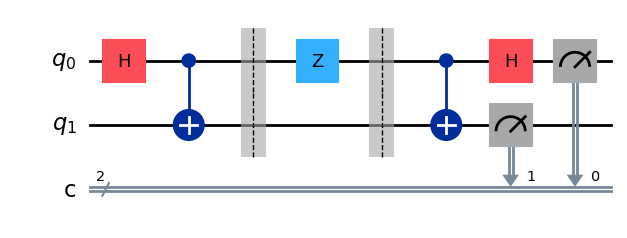

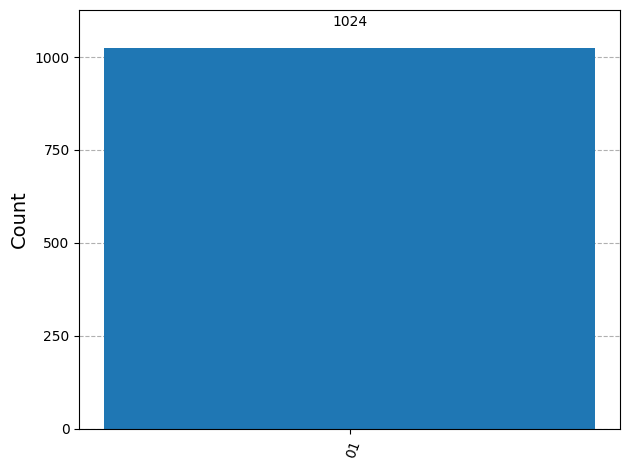

In [37]:
qc_sd = QuantumCircuit(2 , 2)
bit_string = '10'

qc_sd.h(0)
qc_sd.cx(0 , 1)
qc_sd.barrier()

if bit_string[1] == '1' :
    qc_sd.x(0)
if bit_string[0] == '1' :
    qc_sd.z(0)
qc_sd.barrier()

qc_sd.cx(0 , 1)
qc_sd.h(0)

qc_sd.measure([0,1], [0,1])

display(qc_sd.draw('mpl'))

result_sd = simulator.run(qc_sd).result()
plot_histogram(result_sd.get_counts())

**Result:** The final measurement outputs `10`, confirming that two classical bits were successfully transmitted via a single entangled qubit.

### Task 5
**5. Implement a SWAP gate using CNOT gates:**

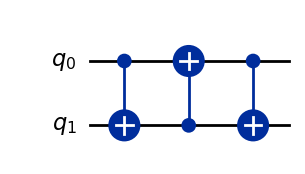

In [39]:
qc_swap = QuantumCircuit(2)

qc_swap.cx(0 , 1)
qc_swap.cx(1 , 0)
qc_swap.cx(0 , 1)

display(qc_swap.draw('mpl'))

**Result:** By chaining three CNOT gates together back-to-back, we successfully swapped the states of the two qubits without needing a dedicated SWAP gate.

### Task 6
**6. Create a circuit that generates the GHZ state $\frac{|0000\rangle + |1111\rangle}{\sqrt{2}}$ for 4 qubits and measure it:**

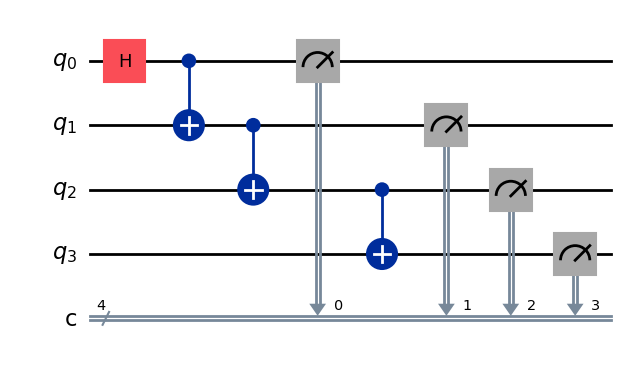

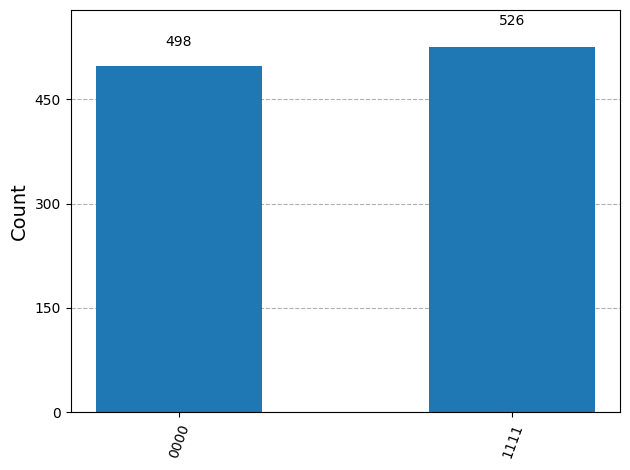

In [42]:
qc_ghz = QuantumCircuit(4, 4)

qc_ghz.h(0)
qc_ghz.cx(0 , 1)
qc_ghz.cx(1 , 2)
qc_ghz.cx(2 , 3)

qc_ghz.measure([0,1,2,3], [0,1,2,3])

display(qc_ghz.draw('mpl'))

result_ghz = simulator.run(qc_ghz).result()
plot_histogram(result_ghz.get_counts())

**Result:** The histogram shows a nearly perfect 50/50 split. This proves all 4 qubits are successfully entangled—measuring them always results in either all zeros (`0000`) or all ones (`1111`).